In [1]:
from pathlib import Path
import numpy as np

import xarray as xr
import rioxarray
import xproj
import ndpyramid
import topozarr

import matplotlib
import matplotlib.pyplot as plt


In [2]:
print(f'Xarray    : {xr.__version__}')
print(f'ndpyramid : {ndpyramid.__version__}')
print(f'topozarr  : {topozarr.__version__}')


Xarray    : 2026.7.0
ndpyramid : 0.4.0
topozarr  : 0.1.6


## Read in `WorldClim` data

In [3]:
# if this returns an empty list, you don't have
# the data downloaded, or it isn't in the right place
data_dir = Path('./data/worldclim/')
[path for path in list(data_dir.glob('*')) if 'wc' in str(path)]


[PosixPath('data/worldclim/wc2.1_10m_prec'),
 PosixPath('data/worldclim/wc2.1_10m_tmax'),
 PosixPath('data/worldclim/wc2.1_10m_tmin'),
 PosixPath('data/worldclim/wc2.1_10m_tavg')]

In [4]:
def open_worldclim_data(path: str, var: str, res: str, version: float) -> xr.Dataset:
    """
    This method takes in one of the available datasets (i.e., `var`) from 
    WorldClim at a given resolution and returns a Xarray Dataset 
    containing all 12 months containing climate averages for each month.

    https://worldclim.org/data/worldclim21.html

    This method assumes that you have downloaded the necessary datasets
    locally and that they are stored within the `path` directory.
    """
    months = list(range(1, 13))

    ds = xr.concat(
        [xr.open_dataset(f'{path}/wc{version}_{res}_{var}/wc{version}_{res}_{var}_{str(month).zfill(2)}.tif', engine='rasterio') for month in months],
        dim='month'
    )

    # add time dim to dataset coordinates
    ds = ds.assign_coords(month=months)

    # remove the 'band' dim from the dataset
    ds = ds.sel(band=1).drop_vars('band')

    # drop attributes and encoding
    ds = ds.drop_attrs()
    ds = ds.drop_encoding()

    # rename data variable
    ds = ds.rename({'band_data': var})

    # set crs
    # ndpyramid looks for rioxarray crs
    ds = ds.rio.write_crs(4326) 
    ds = ds.proj.assign_crs(spatial_ref=4326)

    return ds


In [5]:
# open historical climate data from WorldClim v2.1 at 10 minute resolution
precip = open_worldclim_data(data_dir, 'prec', '10m', 2.1).rename({'prec': 'precip'})
tmin = open_worldclim_data(data_dir, 'tmin', '10m', 2.1)
tavg = open_worldclim_data(data_dir, 'tavg', '10m', 2.1)
tmax = open_worldclim_data(data_dir, 'tmax', '10m', 2.1)

ds_dict = {'tmin': tmin, 'tavg': tavg, 'tmax': tmax, 'precip': precip}
variables = list(ds_dict.keys())
months = list(range(1, 13))


In [6]:
precip


<xarray.Dataset> Size: 112MB
Dimensions:      (month: 12, y: 1080, x: 2160)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * y            (y) float64 9kB 89.92 89.75 89.58 ... -89.58 -89.75 -89.92
  * x            (x) float64 17kB -179.9 -179.8 -179.6 ... 179.6 179.7 179.9
  * spatial_ref  int64 8B 0
Data variables:
    precip       (month, y, x) float32 112MB nan nan nan nan ... 0.0 0.0 0.0 0.0
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)

In [7]:
tmin


<xarray.Dataset> Size: 112MB
Dimensions:      (month: 12, y: 1080, x: 2160)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * y            (y) float64 9kB 89.92 89.75 89.58 ... -89.58 -89.75 -89.92
  * x            (x) float64 17kB -179.9 -179.8 -179.6 ... 179.6 179.7 179.9
  * spatial_ref  int64 8B 0
Data variables:
    tmin         (month, y, x) float32 112MB nan nan nan ... -21.85 -20.51
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)

In [8]:
tavg


<xarray.Dataset> Size: 112MB
Dimensions:      (month: 12, y: 1080, x: 2160)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * y            (y) float64 9kB 89.92 89.75 89.58 ... -89.58 -89.75 -89.92
  * x            (x) float64 17kB -179.9 -179.8 -179.6 ... 179.6 179.7 179.9
  * spatial_ref  int64 8B 0
Data variables:
    tavg         (month, y, x) float32 112MB nan nan nan ... -19.3 -19.28 -18.09
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)

In [9]:
tmax


<xarray.Dataset> Size: 112MB
Dimensions:      (month: 12, y: 1080, x: 2160)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * y            (y) float64 9kB 89.92 89.75 89.58 ... -89.58 -89.75 -89.92
  * x            (x) float64 17kB -179.9 -179.8 -179.6 ... 179.6 179.7 179.9
  * spatial_ref  int64 8B 0
Data variables:
    tmax         (month, y, x) float32 112MB nan nan nan ... -16.72 -16.72 -15.7
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)

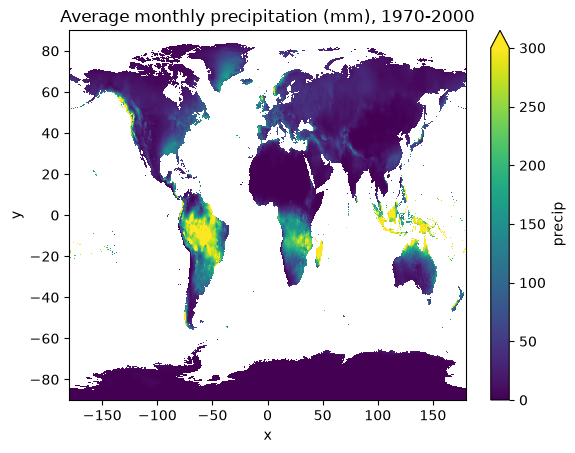

In [10]:
fig, ax = plt.subplots()

precip.sel(month=1).precip.plot(vmin=0, vmax=300, ax=ax)
ax.set_title('Average monthly precipitation (mm), 1970-2000')

plt.show()


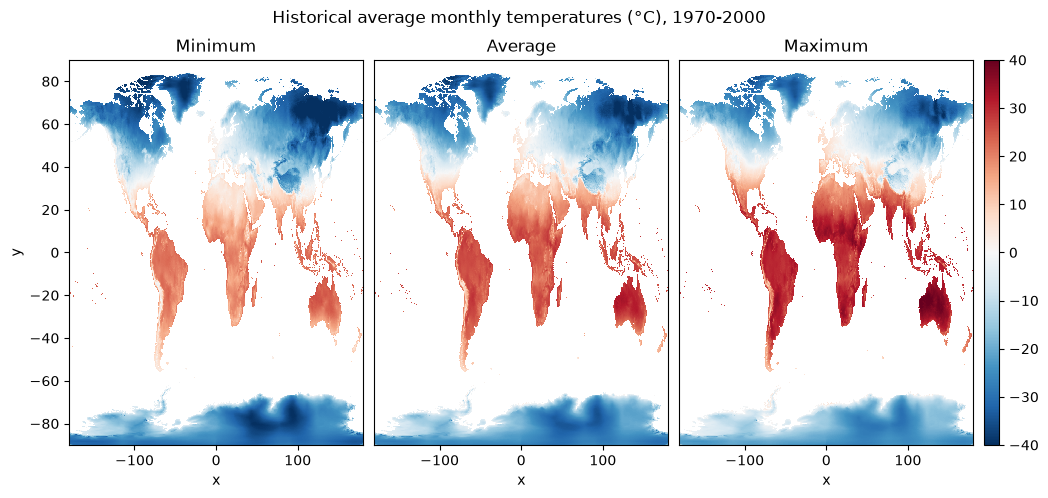

In [11]:
vmin= -40
vmax = 40
cmap = 'RdBu_r'
data_vars = ['tmin', 'tavg', 'tmax', 'prec']

fig = plt.figure(figsize=(12, 5))
axes_dict = fig.subplot_mosaic(
    'ABCD',
    width_ratios=[10, 10, 10, 0.5,],
    gridspec_kw={'hspace':0.05, 'wspace':0.05}
)

cax = axes_dict['D']

for var, ax_name in zip(data_vars[:3], list(axes_dict.keys())[:3]):
    ax = axes_dict[ax_name]

    ds_dict[var].sel(month=1)[var].plot(vmin=vmin, vmax=vmax, cmap=cmap, add_colorbar=False, ax=ax)

    if ax_name in ['B', 'C']:
        # turn off y axis label and ticks
        ax.set_ylabel('')
        ax.set_yticks([])

axes_dict['A'].set_title('Minimum')
axes_dict['B'].set_title('Average')
axes_dict['C'].set_title('Maximum')
fig.suptitle('Historical average monthly temperatures (°C), 1970-2000')

colorbar = fig.colorbar(
    matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin, vmax), cmap=cmap),
    cax=cax
)

plt.show()


### Reshape, chunk data

We are going to try and look at how choices on input data format and chunking affect rendering and querying our data on a web map.

In [12]:
# format data so that individual variables are accessed with ds[variable]
ds_arrays = xr.merge([tmin, tavg, tmax, precip])

# a good chunk schema to start with for viz would be a 1 month, all x-y slice
ds_arrays = ds_arrays.chunk({'month': 1, 'y': -1, 'x': -1})

ds_arrays


<xarray.Dataset> Size: 448MB
Dimensions:      (month: 12, y: 1080, x: 2160)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * y            (y) float64 9kB 89.92 89.75 89.58 ... -89.58 -89.75 -89.92
  * x            (x) float64 17kB -179.9 -179.8 -179.6 ... 179.6 179.7 179.9
  * spatial_ref  int64 8B 0
Data variables:
    tmin         (month, y, x) float32 112MB dask.array<chunksize=(1, 1080, 2160), meta=np.ndarray>
    tavg         (month, y, x) float32 112MB dask.array<chunksize=(1, 1080, 2160), meta=np.ndarray>
    tmax         (month, y, x) float32 112MB dask.array<chunksize=(1, 1080, 2160), meta=np.ndarray>
    precip       (month, y, x) float32 112MB dask.array<chunksize=(1, 1080, 2160), meta=np.ndarray>
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)

In [13]:
# format data so that variables are accessed via 'bands' dim, ds.sel(band=variable)
da = xr.concat([ds_arrays[var] for var in variables], dim='band')
da['band'] = variables
ds_bands = xr.Dataset({'variable': da})[['month', 'band', 'y', 'x', 'variable']]

# fixed-length Unicode strings --> variable-length UTF-8 strings
ds_bands['band'] = ds_bands['band'].values.astype(object)

# here, the data is chunked so that a query only renders a 1 band, 1 month, all x-y slice
ds_bands


<xarray.Dataset> Size: 448MB
Dimensions:      (month: 12, band: 4, y: 1080, x: 2160)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * band         (band) object 32B 'tmin' 'tavg' 'tmax' 'precip'
  * y            (y) float64 9kB 89.92 89.75 89.58 ... -89.58 -89.75 -89.92
  * x            (x) float64 17kB -179.9 -179.8 -179.6 ... 179.6 179.7 179.9
  * spatial_ref  int64 8B 0
Data variables:
    variable     (band, month, y, x) float32 448MB dask.array<chunksize=(1, 1, 1080, 2160), meta=np.ndarray>
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)

One last shape I am interested in exploring is when the data has both variables and bands. This data format is fairly common in weather and climate data, where you also have data variables like temperature and precipitation, but you also have possible 'band' values like `min`, `mean`, `max` over that variable. The temperature data from `WorldClim` already has this structure more or less (e.g., `tmin`, `tavg`, `tmax`), though we will have to create empty, filler arrays for the precipitation data.

In [14]:
# format data so that variables are accessed via 'bands' dim, ds.sel(band=variable)
da_temp = xr.concat([ds_arrays[var] for var in variables[:3]], dim='band')
da_temp['band'] = ['min', 'mean', 'max']
ds_arrays_and_bands = xr.Dataset({'temp': da_temp})[['month', 'band', 'y', 'x', 'temp']]

# the temp data now has bands, but the precipitation data does not
# we can add them by merging the two datasets together while using join='outer'
# this will create empty 'min' and 'max' bands for the precip data, which
# we need to do in this case to keep everything as a single dataset
ds_arrays_and_bands = xr.merge([ds_arrays_and_bands, precip.expand_dims({'band': ['mean']})], join='outer')
ds_arrays_and_bands = ds_arrays_and_bands[['month', 'band', 'y', 'x', 'temp', 'precip']]

# same as ds_bands, each chunk is a 1 band, 1 month, all x-y slice
ds_arrays_and_bands = ds_arrays_and_bands.chunk({'band': 1, 'month': 1, 'y': -1, 'x': -1})

ds_arrays_and_bands


<xarray.Dataset> Size: 672MB
Dimensions:      (month: 12, band: 3, y: 1080, x: 2160)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * band         (band) object 24B 'max' 'mean' 'min'
  * y            (y) float64 9kB 89.92 89.75 89.58 ... -89.58 -89.75 -89.92
  * x            (x) float64 17kB -179.9 -179.8 -179.6 ... 179.6 179.7 179.9
  * spatial_ref  int64 8B 0
Data variables:
    temp         (band, month, y, x) float32 336MB dask.array<chunksize=(1, 1, 1080, 2160), meta=np.ndarray>
    precip       (band, month, y, x) float32 336MB dask.array<chunksize=(1, 1, 1080, 2160), meta=np.ndarray>
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)

In [15]:
ds_arrays_and_bands.sel(band='mean').temp


<xarray.DataArray 'temp' (month: 12, y: 1080, x: 2160)> Size: 112MB
dask.array<getitem, shape=(12, 1080, 2160), dtype=float32, chunksize=(1, 1080, 2160), chunktype=numpy.ndarray>
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * y            (y) float64 9kB 89.92 89.75 89.58 ... -89.58 -89.75 -89.92
  * x            (x) float64 17kB -179.9 -179.8 -179.6 ... 179.6 179.7 179.9
    band         <U4 16B 'mean'
  * spatial_ref  int64 8B 0
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)

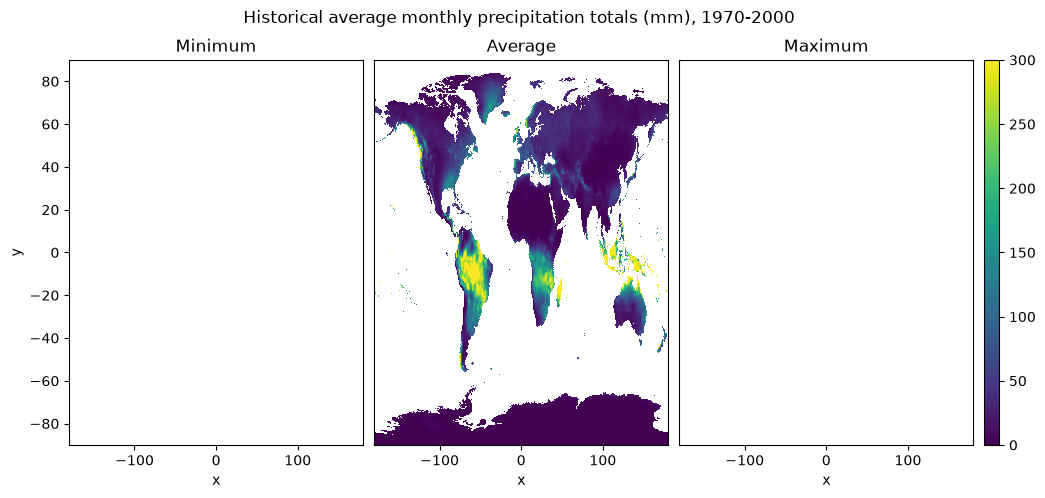

In [16]:
vmin= 0
vmax = 300
cmap = 'viridis'
bands = ['min', 'mean', 'max']

# the 'min' and 'max' bands should be empty
fig = plt.figure(figsize=(12, 5))
axes_dict = fig.subplot_mosaic(
    'ABCD',
    width_ratios=[10, 10, 10, 0.5,],
    gridspec_kw={'hspace':0.05, 'wspace':0.05}
)

cax = axes_dict['D']

for band, ax_name in zip(bands, list(axes_dict.keys())[:3]):
    ax = axes_dict[ax_name]

    ds_arrays_and_bands.sel(month=1, band=band).precip.plot(vmin=0, vmax=300, add_colorbar=False, ax=ax)

    if ax_name in ['B', 'C']:
        # turn off y axis label and ticks
        ax.set_ylabel('')
        ax.set_yticks([])

axes_dict['A'].set_title('Minimum')
axes_dict['B'].set_title('Average')
axes_dict['C'].set_title('Maximum')
fig.suptitle('Historical average monthly precipitation totals (mm), 1970-2000')

colorbar = fig.colorbar(
    matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin, vmax, cmap)),
    cax=cax
)

plt.show()


## Create `Zarr` stores


### `ndpyramid`

The `ndpyramid` package does not let you create a single-level `Zarr` at native resolution (or even reprojected) without nesting, so we will be creating pyramids below. However, we can still experiment with using bands vs separate arrays. For example, if you try to run:
```python
pixels_per_tile = 128
longitude_length = ds.x.shape[0]
max_levels = round(np.sqrt(longitude_length / pixels_per_tile)) + 1
levels = max_levels

dt = ndpyramid.pyramid_reproject(
    ds.drop_encoding(),
    levels=0,
    extra_dim=...,
    other_chunks={...},
)
```

You will get the error:
```
NotImplementedError: Automatic determination of number of levels is not yet implemented
```


In [19]:
def create_ndpyramid_store(ds: xr.Dataset, extra_dim: str, other_chunks: dict, name: str) -> xr.DataTree:
    """
    For a given input dataset `ds`, calculate the number of levels
    needed for a Zarr pyramid using the `ndpyramid` package. Then,
    save the pyramid to a GCS bucket.

    This method assums that the 'lat', 'lon' dimensions are named 'y', 'x'.
    """
    bucket_path = f'gs://zarr-layer-demo/zarr/ndpyramid-v2-{name}.zarr'

    # calculate the number of zoom levels to use for the output Zarr
    pixels_per_tile = 128
    longitude_length = ds.x.shape[0]
    max_levels = round(np.sqrt(longitude_length / pixels_per_tile)) + 1
    levels = max_levels
    print(f'Number of levels in pyramid: {levels}')

    # create data pyramid
    dt = ndpyramid.pyramid_reproject(
        ds.drop_encoding(),
        levels=levels,
        extra_dim=extra_dim,
        other_chunks=other_chunks,
    )

    # save data tree to Zarr store in bucket
    # we will stick with Zarr v2 and consolidated metadata for now
    # dt.to_zarr(bucket_path, zarr_format=2, consolidated=True, mode='w')

    return dt
    

In [20]:
dt_arrays = create_ndpyramid_store(
    ds_arrays, 
    extra_dim='month', 
    other_chunks={'month': len(months)},
    name='arrays'
)

dt_arrays


Number of levels in pyramid: 5


<xarray.DataTree>
Group: /
│   Attributes:
│       multiscales:  [{'datasets': [{'path': '0', 'level': 0, 'crs': 'EPSG:3857'...
│       title:        multiscale data pyramid
│       version:      0.4.0
├── Group: /0
│       Dimensions:      (month: 12, y: 128, x: 128)
│       Coordinates:
│         * month        (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
│         * y            (y) float32 512B 1.988e+07 1.957e+07 ... -1.957e+07 -1.988e+07
│         * x            (x) float32 512B -1.988e+07 -1.957e+07 ... 1.957e+07 1.988e+07
│           spatial_ref  int32 4B 0
│       Data variables:
│           tmin         (month, y, x) float32 786kB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│           tavg         (month, y, x) float32 786kB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│           tmax         (month, y, x) float32 786kB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│           precip       (month, y, x) float32 786kB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│       Attributes:
│           multiscales:  [{'datasets': [{'path': '.', 'level': 0, 'crs': 'EPSG:3857'...
├── Group: /1
│       Dimensions:      (month: 12, y: 256, x: 256)
│       Coordinates:
│         * month        (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
│         * y            (y) float32 1kB 1.996e+07 1.98e+07 ... -1.98e+07 -1.996e+07
│         * x            (x) float32 1kB -1.996e+07 -1.98e+07 ... 1.98e+07 1.996e+07
│           spatial_ref  int32 4B 0
│       Data variables:
│           tmin         (month, y, x) float32 3MB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│           tavg         (month, y, x) float32 3MB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│           tmax         (month, y, x) float32 3MB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│           precip       (month, y, x) float32 3MB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│       Attributes:
│           multiscales:  [{'datasets': [{'path': '.', 'level': 1, 'crs': 'EPSG:3857'...
├── Group: /2
│       Dimensions:      (month: 12, y: 512, x: 512)
│       Coordinates:
│         * month        (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
│         * y            (y) float32 2kB 2e+07 1.992e+07 1.984e+07 ... -1.992e+07 -2e+07
│         * x            (x) float32 2kB -2e+07 -1.992e+07 ... 1.992e+07 2e+07
│           spatial_ref  int32 4B 0
│       Data variables:
│           tmin         (month, y, x) float32 13MB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│           tavg         (month, y, x) float32 13MB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│           tmax         (month, y, x) float32 13MB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│           precip       (month, y, x) float32 13MB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│       Attributes:
│           multiscales:  [{'datasets': [{'path': '.', 'level': 2, 'crs': 'EPSG:3857'...
├── Group: /3
│       Dimensions:      (month: 12, y: 1024, x: 1024)
│       Coordinates:
│         * month        (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
│         * y            (y) float32 4kB 2.002e+07 1.998e+07 ... -1.998e+07 -2.002e+07
│         * x            (x) float32 4kB -2.002e+07 -1.998e+07 ... 1.998e+07 2.002e+07
│           spatial_ref  int32 4B 0
│       Data variables:
│           tmin         (month, y, x) float32 50MB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│           tavg         (month, y, x) float32 50MB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│           tmax         (month, y, x) float32 50MB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│           precip       (month, y, x) float32 50MB dask.array<chunksize=(12, 128, 128), meta=np.ndarray>
│       Attributes:
│           multiscales:  [{'datasets': [{'path': '.', 'level': 3, 'crs': 'EPSG:3857'...
└── Group: /4
        Dimensions:      (month: 12, y: 2048, x: 2048)
        Coordinates:
          * mo

In [19]:
dt_bands = create_ndpyramid_store(
    ds_bands, 
    extra_dim='band', 
    other_chunks={'month': len(months), 'band': len(variables)},
    name='bands'
)

dt_bands


Number of levels in pyramid: 5


<xarray.DataTree>
Group: /
│   Attributes:
│       multiscales:  [{'datasets': [{'path': '0', 'level': 0, 'crs': 'EPSG:3857'...
│       title:        multiscale data pyramid
│       version:      0.4.0
├── Group: /0
│       Dimensions:      (band: 4, month: 12, y: 128, x: 128)
│       Coordinates:
│         * band         (band) <U6 96B 'tmin' 'tavg' 'tmax' 'precip'
│         * month        (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
│         * y            (y) float32 512B 1.988e+07 1.957e+07 ... -1.957e+07 -1.988e+07
│         * x            (x) float32 512B -1.988e+07 -1.957e+07 ... 1.957e+07 1.988e+07
│           spatial_ref  int32 4B 0
│       Data variables:
│           variable     (band, month, y, x) float32 3MB dask.array<chunksize=(4, 12, 128, 128), meta=np.ndarray>
│       Attributes:
│           multiscales:  [{'datasets': [{'path': '.', 'level': 0, 'crs': 'EPSG:3857'...
├── Group: /1
│       Dimensions:      (band: 4, month: 12, y: 256, x: 256)
│       Coordinates:
│         * band         (band) <U6 96B 'tmin' 'tavg' 'tmax' 'precip'
│         * month        (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
│         * y            (y) float32 1kB 1.996e+07 1.98e+07 ... -1.98e+07 -1.996e+07
│         * x            (x) float32 1kB -1.996e+07 -1.98e+07 ... 1.98e+07 1.996e+07
│           spatial_ref  int32 4B 0
│       Data variables:
│           variable     (band, month, y, x) float32 13MB dask.array<chunksize=(4, 12, 128, 128), meta=np.ndarray>
│       Attributes:
│           multiscales:  [{'datasets': [{'path': '.', 'level': 1, 'crs': 'EPSG:3857'...
├── Group: /2
│       Dimensions:      (band: 4, month: 12, y: 512, x: 512)
│       Coordinates:
│         * band         (band) <U6 96B 'tmin' 'tavg' 'tmax' 'precip'
│         * month        (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
│         * y            (y) float32 2kB 2e+07 1.992e+07 1.984e+07 ... -1.992e+07 -2e+07
│         * x            (x) float32 2kB -2e+07 -1.992e+07 ... 1.992e+07 2e+07
│           spatial_ref  int32 4B 0
│       Data variables:
│           variable     (band, month, y, x) float32 50MB dask.array<chunksize=(4, 12, 128, 128), meta=np.ndarray>
│       Attributes:
│           multiscales:  [{'datasets': [{'path': '.', 'level': 2, 'crs': 'EPSG:3857'...
├── Group: /3
│       Dimensions:      (band: 4, month: 12, y: 1024, x: 1024)
│       Coordinates:
│         * band         (band) <U6 96B 'tmin' 'tavg' 'tmax' 'precip'
│         * month        (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
│         * y            (y) float32 4kB 2.002e+07 1.998e+07 ... -1.998e+07 -2.002e+07
│         * x            (x) float32 4kB -2.002e+07 -1.998e+07 ... 1.998e+07 2.002e+07
│           spatial_ref  int32 4B 0
│       Data variables:
│           variable     (band, month, y, x) float32 201MB dask.array<chunksize=(4, 12, 128, 128), meta=np.ndarray>
│       Attributes:
│           multiscales:  [{'datasets': [{'path': '.', 'level': 3, 'crs': 'EPSG:3857'...
└── Group: /4
        Dimensions:      (band: 4, month: 12, y: 2048, x: 2048)
        Coordinates:
          * band         (band) <U6 96B 'tmin' 'tavg' 'tmax' 'precip'
          * month        (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
          * y            (y) float32 8kB 2.003e+07 2.001e+07 ... -2.001e+07 -2.003e+07
          * x            (x) float32 8kB -2.003e+07 -2.001e+07 ... 2.001e+07 2.003e+07
            spatial_ref  int32 4B 0
        Data variables:
            variable     (band, month, y, x) float32 805MB dask.array<chunksize=(4, 12, 128, 128), meta=np.ndarray>
        Attributes:
            multiscales:  [{'datasets': [{'path': '.', 'level': 4, 'crs': 'EPSG:3857'...

In [20]:
dt_bands_and_arrays = create_ndpyramid_store(
    ds_arrays_and_bands, 
    extra_dim='band',
    other_chunks={'month': len(months), 'band': len(bands)},
    name='arrays-and-bands'
)

dt_bands_and_arrays


Number of levels in pyramid: 5


<xarray.DataTree>
Group: /
│   Attributes:
│       multiscales:  [{'datasets': [{'path': '0', 'level': 0, 'crs': 'EPSG:3857'...
│       title:        multiscale data pyramid
│       version:      0.4.0
├── Group: /0
│       Dimensions:      (band: 3, month: 12, y: 128, x: 128)
│       Coordinates:
│         * band         (band) <U4 48B 'max' 'mean' 'min'
│         * month        (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
│         * y            (y) float32 512B 1.988e+07 1.957e+07 ... -1.957e+07 -1.988e+07
│         * x            (x) float32 512B -1.988e+07 -1.957e+07 ... 1.957e+07 1.988e+07
│           spatial_ref  int32 4B 0
│       Data variables:
│           temp         (band, month, y, x) float32 2MB dask.array<chunksize=(3, 12, 128, 128), meta=np.ndarray>
│           precip       (band, month, y, x) float32 2MB dask.array<chunksize=(3, 12, 128, 128), meta=np.ndarray>
│       Attributes:
│           multiscales:  [{'datasets': [{'path': '.', 'level': 0, 'crs': 'EPSG:3857'...
├── Group: /1
│       Dimensions:      (band: 3, month: 12, y: 256, x: 256)
│       Coordinates:
│         * band         (band) <U4 48B 'max' 'mean' 'min'
│         * month        (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
│         * y            (y) float32 1kB 1.996e+07 1.98e+07 ... -1.98e+07 -1.996e+07
│         * x            (x) float32 1kB -1.996e+07 -1.98e+07 ... 1.98e+07 1.996e+07
│           spatial_ref  int32 4B 0
│       Data variables:
│           temp         (band, month, y, x) float32 9MB dask.array<chunksize=(3, 12, 128, 128), meta=np.ndarray>
│           precip       (band, month, y, x) float32 9MB dask.array<chunksize=(3, 12, 128, 128), meta=np.ndarray>
│       Attributes:
│           multiscales:  [{'datasets': [{'path': '.', 'level': 1, 'crs': 'EPSG:3857'...
├── Group: /2
│       Dimensions:      (band: 3, month: 12, y: 512, x: 512)
│       Coordinates:
│         * band         (band) <U4 48B 'max' 'mean' 'min'
│         * month        (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
│         * y            (y) float32 2kB 2e+07 1.992e+07 1.984e+07 ... -1.992e+07 -2e+07
│         * x            (x) float32 2kB -2e+07 -1.992e+07 ... 1.992e+07 2e+07
│           spatial_ref  int32 4B 0
│       Data variables:
│           temp         (band, month, y, x) float32 38MB dask.array<chunksize=(3, 12, 128, 128), meta=np.ndarray>
│           precip       (band, month, y, x) float32 38MB dask.array<chunksize=(3, 12, 128, 128), meta=np.ndarray>
│       Attributes:
│           multiscales:  [{'datasets': [{'path': '.', 'level': 2, 'crs': 'EPSG:3857'...
├── Group: /3
│       Dimensions:      (band: 3, month: 12, y: 1024, x: 1024)
│       Coordinates:
│         * band         (band) <U4 48B 'max' 'mean' 'min'
│         * month        (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
│         * y            (y) float32 4kB 2.002e+07 1.998e+07 ... -1.998e+07 -2.002e+07
│         * x            (x) float32 4kB -2.002e+07 -1.998e+07 ... 1.998e+07 2.002e+07
│           spatial_ref  int32 4B 0
│       Data variables:
│           temp         (band, month, y, x) float32 151MB dask.array<chunksize=(3, 12, 128, 128), meta=np.ndarray>
│           precip       (band, month, y, x) float32 151MB dask.array<chunksize=(3, 12, 128, 128), meta=np.ndarray>
│       Attributes:
│           multiscales:  [{'datasets': [{'path': '.', 'level': 3, 'crs': 'EPSG:3857'...
└── Group: /4
        Dimensions:      (band: 3, month: 12, y: 2048, x: 2048)
        Coordinates:
          * band         (band) <U4 48B 'max' 'mean' 'min'
          * month        (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
          * y            (y) float32 8kB 2.003e+07 2.001e+07 ... -2.001e+07 -2.003e+07
          * x            (x) float32 8kB -2.003e+07 -2.001e+07 ... 2.001e+07 2.003e+07
            spatial_ref  int32 4B 0
        Data variables:
            temp         (band, month, y, x) float32 604MB dask.array<chunksize=(3, 12, 128, 128), meta=np.ndarray>
            precip       (band, 

### `topozarr`

Since the data isn't too granular, we are going to create 'flat' `Zarr` stores of the data at native resolution.

In [23]:
def create_topozarr_store(ds: xr.Dataset, name: str, version: int = 3, pyramid: bool = False, chunks: dict | None = None) -> None:
    """
    For a given input dataset `ds`, create a 'flat' Zarr store for data
    viz using the `topozarr` package. Then, save the pyramid to a GCS bucket.

    This method assums that the 'lat', 'lon' dimensions are named 'y', 'x'.
    """
    bucket_path = f"gs://zarr-layer-demo/zarr/topozarr-v{version}-{name}{'-pyramid' if pyramid == True else ''}.zarr"
    
    if pyramid:
        # https://carbonplan.github.io/topozarr/usage/#basic-example
        pyramid = topozarr.create_pyramid(
            ds,
            factors=[1, 4, 16],
            x_dim='x',
            y_dim='y',
            method='mean',
            # https://noc-oi.github.io/cloud-native-geoscience-course/15-visualisation.html#topozarr-creating-multiscale-zarr-for-visualisation
            # target chunk size in bytes (e.g. 128x128 pixels with float32)
            target_chunk_bytes=128 * 128 * 4,
            chunks_per_shard=4 if version == 3 else None,
        )

        dt = pyramid.as_datatree()

        dt.to_zarr(
            bucket_path, 
            zarr_format=version,
            consolidated=False if version == 3 else True,
            encoding=pyramid.encoding,
            mode='w',
        )

        # return dt

    else:
        # create 'flat' Zarr store
        # https://carbonplan.github.io/topozarr/usage/#metadata-only-no-pyramid
        # attach metadata, save to bucket
        ds = topozarr.attach_geozarr_metadata(ds, x_dim='x', y_dim='y')
        
        if chunks is not None:
            ds = ds.chunk(chunks)
    
        # save data tree to Zarr store in bucket
        # consolidated metadata not supported in Zarr v3
        ds.to_zarr(
            bucket_path, 
            zarr_format=version,
            consolidated=False if version == 3 else True,
            # the `encoding` parameter is causing issues reading the data in `zarr-layer`
            # encoding=None if version == 2 else topozarr.recommend_encoding(ds, x_dim='x', y_dim='y'),
        )
    

In [ ]:
# create v3 flat Zarrs
create_topozarr_store(ds_arrays, 'arrays')
create_topozarr_store(ds_bands, 'bands')
create_topozarr_store(ds_arrays_and_bands, 'arrays-and-bands')


In [71]:
# create v2 flat Zarrs
create_topozarr_store(ds_arrays, 'arrays', version=2)
create_topozarr_store(ds_bands, 'bands', version=2)
create_topozarr_store(ds_arrays_and_bands, 'arrays-and-bands', version=2)


In [31]:
# create v3 Zarr pyramid
create_topozarr_store(ds_arrays, 'arrays', pyramid=True)
create_topozarr_store(ds_bands, 'bands', pyramid=True)
create_topozarr_store(ds_arrays_and_bands, 'arrays-and-bands', pyramid=True)


ValueError: Specified Zarr chunks encoding['chunks']=(2, 256, 512) for variable named 'precip' would overlap multiple Dask chunks. Please check the Dask chunks at position 1 and 2, on axis 0, they are overlapped on the same Zarr chunk in the region slice(None, None, None). Writing this array in parallel with Dask could lead to corrupted data. To resolve this issue, consider one of the following options: - Rechunk the array using `chunk()`. - Modify or delete `encoding['chunks']`. - Set `safe_chunks=False`. - Enable automatic chunks alignment with `align_chunks=True`.

In [40]:
# create v2 Zarr pyramid
create_topozarr_store(ds_arrays, 'arrays', version=2, pyramid=True)
create_topozarr_store(ds_bands, 'bands', version=2, pyramid=True)
create_topozarr_store(ds_arrays_and_bands, 'arrays-and-bands', version=2, pyramid=True)


In [41]:
# https://carbonplan.github.io/topozarr/api/#topozarr.metadata.recommend_encoding
enc = topozarr.recommend_encoding(ds_arrays)['precip']
enc


{'chunks': (1, 270, 270), 'shards': (1, 1080, 1080)}

In [42]:
enc = topozarr.recommend_encoding(ds_bands)['variable']
enc


{'chunks': (1, 1, 270, 270), 'shards': (1, 1, 1080, 1080)}

In [43]:
enc = topozarr.recommend_encoding(ds_arrays_and_bands)['temp']
enc


{'chunks': (1, 1, 270, 270), 'shards': (1, 1, 1080, 1080)}

In [67]:
version = 2

pyramid = topozarr.create_pyramid(
    ds_bands,
    factors=[1, 4, 16],
    x_dim='x',
    y_dim='y',
    method='mean',
    # https://noc-oi.github.io/cloud-native-geoscience-course/15-visualisation.html#topozarr-creating-multiscale-zarr-for-visualisation
    # target chunk size in bytes (e.g. 128x128 pixels with float32)
    # target_chunk_bytes=128 * 128 * 4,
    # chunks_per_shard=4 if version == 3 else None,
)

pyramid


Pyramid(source=<xarray.Dataset> Size: 448MB
Dimensions:      (month: 12, band: 4, y: 1080, x: 2160)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * band         (band) object 32B 'tmin' 'tavg' 'tmax' 'precip'
  * y            (y) float64 9kB 89.92 89.75 89.58 ... -89.58 -89.75 -89.92
  * x            (x) float64 17kB -179.9 -179.8 -179.6 ... 179.6 179.7 179.9
  * spatial_ref  int64 8B 0
Data variables:
    variable     (band, month, y, x) float32 448MB dask.array<chunksize=(1, 1, 1080, 2160), meta=np.ndarray>
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326), level_templates={0: <xarray.Dataset> Size: 448MB
Dimensions:      (month: 12, band: 4, y: 1080, x: 2160)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * band         (band) object 32B 'tmin' 'tavg' 'tmax' 'precip'
  * y            (y) float64 9kB 89.92 89.75 89.58 ... -89.58 -89.75 -89.92
  * x            (x) float64 17kB -179.9 -179.8 -179.6 ... 179.6 179.7 179.9
  * 

In [68]:
pyramid.encoding


{'/0': {'variable': {'chunks': (1, 1, 270, 270),
   'shards': (1, 1, 1080, 1080)}},
 '/1': {'variable': {'chunks': (1, 1, 270, 270), 'shards': (1, 12, 270, 540)}},
 '/2': {'variable': {'chunks': (1, 1, 67, 135), 'shards': (4, 12, 67, 135)}}}

In [69]:
dt = pyramid.as_datatree()
dt


<xarray.DataTree>
Group: /
│   Attributes:
│       zarr_conventions:      [{'schema_url': 'https://raw.githubusercontent.com...
│       proj:code:             EPSG:4326
│       proj:wkt2:             GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1...
│       spatial:dimensions:    ['y', 'x']
│       spatial:registration:  pixel
│       spatial:transform:     [0.1666666666666572, 0.0, -180.0, 0.0, -0.16666666...
│       spatial:bbox:          [-180.0, -90.00000000000512, 179.99999999997954, 9...
│       spatial:shape:         [1080, 2160]
│       multiscales:           {'layout': [{'asset': '0', 'spatial:transform': [0...
├── Group: /0
│       Dimensions:      (month: 12, band: 4, y: 1080, x: 2160)
│       Coordinates:
│         * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
│         * band         (band) object 32B 'tmin' 'tavg' 'tmax' 'precip'
│         * y            (y) float64 9kB 89.92 89.75 89.58 ... -89.58 -89.75 -89.92
│         * x            (x) float64 17kB -179.9 -179.8 -179.6 ... 179.6 179.7 179.9
│         * spatial_ref  int64 8B 0
│       Data variables:
│           variable     (band, month, y, x) float32 448MB dask.array<chunksize=(1, 1, 1080, 2160), meta=np.ndarray>
│       Indexes:
│           spatial_ref  CRSIndex (crs=EPSG:4326)
├── Group: /1
│       Dimensions:      (band: 4, month: 12, y: 270, x: 540)
│       Coordinates:
│         * band         (band) object 32B 'tmin' 'tavg' 'tmax' 'precip'
│         * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
│         * y            (y) float64 2kB 89.67 89.0 88.33 87.67 ... -88.33 -89.0 -89.67
│         * x            (x) float64 4kB -179.7 -179.0 -178.3 ... 178.3 179.0 179.7
│           spatial_ref  int64 8B 0
│       Data variables:
│           variable     (band, month, y, x) float32 28MB dask.array<chunksize=(1, 1, 270, 540), meta=np.ndarray>
└── Group: /2
        Dimensions:      (band: 4, month: 12, y: 67, x: 135)
        Coordinates:
          * band         (band) object 32B 'tmin' 'tavg' 'tmax' 'precip'
          * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
          * y            (y) float64 536B 88.67 86.0 83.33 80.67 ... -82.0 -84.67 -87.33
          * x            (x) float64 1kB -178.7 -176.0 -173.3 ... 173.3 176.0 178.7
            spatial_ref  int64 8B 0
        Data variables:
            variable     (band, month, y, x) float32 2MB dask.array<chunksize=(1, 1, 67, 135), meta=np.ndarray>